# Sequnece Model Practice

- Conv1d + LSTM 기반 주가 예측 확장 실습:
 `Open`, `High`, `Low`, `Close`, `Volume`과 파생 feature를 함께 사용해 다변량 시계열 데이터를 구성한다.

## 1. 라이브러리 불러오기

필요한 라이브러리를 불러온다. `FinanceDataReader`가 설치되어 있지 않다면 아래 설치 코드를 먼저 실행한다.


In [16]:
# %pip install finance-datareader

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import FinanceDataReader as fdr

## 2. 데이터 불러오기

In [18]:
# 종목 코드 설정
naver_code = '035420'

# FinanceDataReader를 사용하여 네이버 주가 데이터를 가져오기
naver = fdr.DataReader(naver_code)

naver.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2014-02-06,144203,152013,143602,148009,428072,NaN
2014-02-07,150413,151214,146407,150413,186951,0.016242
2014-02-10,150010,150811,147007,147008,132548,-0.022638
2014-02-11,147809,149612,146607,147609,98646,0.004088
2014-02-12,148810,149210,146406,148410,68665,0.005426


In [19]:
# 데이터 기본 정보 확인
print(naver.shape)
print(naver.isna().sum())
naver.tail()

(3000, 6)
Open      0
High      0
Low       0
Close     0
Volume    0
Change    1
dtype: int64


,Open,High,Low,Close,Volume,Change
Date,,,,,,
2026-04-21,215000,215500,211500,214000,545889,0.002342
2026-04-22,215000,216000,212500,214000,364648,0.000000
2026-04-23,220500,221000,213000,217500,800536,0.016355
2026-04-24,216000,216500,213000,214000,476096,-0.016092
2026-04-27,216000,218500,215000,215000,458738,0.004673


## 3. feature 구성

다음 feature를 사용한다.

- `Open`: 시가
- `High`: 고가
- `Low`: 저가
- `Close`: 종가
- `Volume`: 거래량
- `MA5`: 5일 이동평균
- `MA20`: 20일 이동평균
- `Return`: 일별 수익률
- `Range`: 하루 변동폭 비율

정답값 `target`은 다음 날의 `Close`이다.

### feature 선택 이유

원본 가격 정보와 간단한 파생 feature를 함께 사용한다.

- `Open`, `High`, `Low`, `Close`: 하루 동안의 가격 수준과 가격 움직임을 나타내는 기본 정보이다.
- `Volume`: 해당 날짜의 거래 규모를 나타내며, 가격 움직임과 함께 시장의 관심도를 간접적으로 볼 수 있다.
- `MA5`: 최근 5일의 단기 추세를 보기 위한 feature이다.
- `MA20`: 최근 20일의 중기 추세를 보기 위한 feature이다.
- `Return`: 전날 대비 종가 변화율로, 가격의 상대적인 변화 방향과 크기를 볼 수 있다.
- `Range`: 하루 동안 고가와 저가의 차이를 종가 기준으로 나눈 값이며, 일중 변동성을 나타낸다.

단, feature를 많이 넣는다고 항상 성능이 좋아지는 것은 아니다. 예측에 도움이 되지 않는 feature는 노이즈가 될 수 있고, feature 수가 많아질수록 과적합 가능성도 커질 수 있다.

In [20]:
# 원본 데이터 복사
stock_df = naver.copy()

# 5일 이동평균: 최근 5일 종가 평균
stock_df['MA5'] = stock_df['Close'].rolling(window=5).mean()

# 20일 이동평균: 최근 20일 종가 평균
stock_df['MA20'] = stock_df['Close'].rolling(window=20).mean()

# 일별 수익률: 전날 대비 종가 변화 비율
stock_df['Return'] = stock_df['Close'].pct_change()

# 하루 변동폭 비율: 고가와 저가 차이를 종가 기준으로 환산
stock_df['Range'] = (stock_df['High'] - stock_df['Low']) / stock_df['Close']

# 이동평균과 수익률 계산으로 생긴 결측치 제거
stock_df = stock_df.dropna()

stock_df.head()

,Open,High,Low,Close,Volume,Change,MA5,MA20,Return,Range
Date,,,,,,,,,,
2014-03-05,166836,171643,166235,170642,149905,0.036499,164072.4,151414.30,0.036499,0.031692
2014-03-06,176248,176248,166635,167437,205735,-0.018782,165834.8,152385.70,-0.018782,0.057413
2014-03-07,168236,170039,165033,165434,122436,-0.011963,166195.2,153136.75,-0.011963,0.030260
2014-03-10,166836,171643,166235,170842,132318,0.032690,167797.6,154328.45,0.032690,0.031655
2014-03-11,173045,175649,168238,170241,110850,-0.003518,168919.2,155460.05,-0.003518,0.043532


In [21]:
# 사용할 feature 목록
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA5', 'MA20', 'Return', 'Range']
target_col = 'Close'

# feature 데이터와 target 데이터 분리
features = stock_df[feature_cols].values
target = stock_df[[target_col]].values

print(features.shape)
print(target.shape)

(2981, 9)
(2981, 1)


## 4. 스케일링

feature와 target은 값의 범위가 다르다. 예를 들어 거래량은 가격보다 훨씬 큰 값을 가진다. 따라서 feature와 target을 각각 스케일링한다.

### 수정 안내

전체 데이터를 먼저 스케일링한 뒤 학습/검증 데이터를 나누는 흐름으로 제시되어 있으나 이 때 검증 데이터의 최솟값과 최댓값 정보가 scaler에 반영되는 데이터 누수가 발생할 수 있다.

따라서 다음처럼 수정한다.

In [22]:
# feature용 scaler와 target용 scaler를 각각 생성
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# 시계열 순서를 유지한 상태에서 학습 구간 기준점 설정
# 이 기준점보다 앞쪽 데이터만 scaler fit에 사용한다.
train_boundary = int(len(stock_df) * 0.8)

train_features_raw = stock_df[feature_cols].iloc[:train_boundary].values
train_target_raw = stock_df[[target_col]].iloc[:train_boundary].values

# scaler는 학습 구간에 대해서만 fit한다.
feature_scaler.fit(train_features_raw)
target_scaler.fit(train_target_raw)

# 학습 구간에서 fit한 scaler로 전체 데이터를 transform한다.
# 검증 구간의 값은 scaler 학습에 사용되지 않는다.
features_scaled = feature_scaler.transform(stock_df[feature_cols].values)
target_scaled = target_scaler.transform(stock_df[[target_col]].values)

print('train_boundary:', train_boundary)
print(features_scaled.shape)
print(target_scaled.shape)


train_boundary: 2384
(2981, 9)
(2981, 1)


## 5. 다변량 시계열 학습 데이터 생성

`window_size=20`이면 과거 20일의 여러 feature를 입력으로 사용하고, 그 다음 날의 종가를 정답으로 사용한다.

생성되는 입력 shape은 다음과 같다.

```text
X: (샘플 개수, window_size, feature 수)
y: (샘플 개수, 1)
```


In [23]:
def create_multivariate_dataset(features, target, window_size=20):
    X, y = [], []

    # 과거 window_size일의 feature를 입력으로 사용하고,
    # 바로 다음 날의 target 값을 정답으로 사용한다.
    for i in range(len(features) - window_size):
        inputs = features[i: i + window_size]
        label = target[i + window_size]
        X.append(inputs)
        y.append(label)

    return np.array(X), np.array(y)


window_size = 20
X, y = create_multivariate_dataset(features_scaled, target_scaled, window_size)

print(X.shape)
print(y.shape)

(2961, 20, 9)
(2961, 1)


## 6. Tensor 변환 및 학습/검증 분리

시계열 데이터는 순서가 중요하므로 무작위 분리하지 않고 앞쪽 80%를 학습 데이터, 뒤쪽 20%를 검증 데이터로 사용한다.


In [24]:
# numpy 배열을 torch tensor로 변환
X_tensor = torch.tensor(X, dtype=torch.float)
y_tensor = torch.tensor(y, dtype=torch.float)

# 앞쪽 80%를 학습 데이터로 사용
train_size = int(len(X_tensor) * 0.8)
X_train, X_val = X_tensor[:train_size], X_tensor[train_size:]
y_train, y_val = y_tensor[:train_size], y_tensor[train_size:]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

torch.Size([2368, 20, 9]) torch.Size([2368, 1])
torch.Size([593, 20, 9]) torch.Size([593, 1])


## 7. Conv1d + LSTM 모델 정의

`input_size`는 feature 개수이다. 
즉 `Open`, `High`, `Low`, `Close`, `Volume`, `MA5`, `MA20`, `Return`, `Range`를 사용하면 `input_size=9`가 된다.

Conv1d는 `(batch_size, channel, seq_len)` 형태를 요구한다. 하지만 LSTM용 데이터는 `(batch_size, seq_len, feature 수)` 형태이므로 `permute()`가 필요하다.

In [25]:
class StockConvLSTM(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers, conv_filters, conv_kernel_size):
        super().__init__()

        # Conv1d: 여러 feature를 가진 시계열에서 짧은 구간 패턴을 추출
        # input_size는 feature 수, conv_filters는 추출할 패턴 특징 수이다.
        self.conv1d = nn.Conv1d(
            in_channels=input_size,
            out_channels=conv_filters,
            kernel_size=conv_kernel_size,
            padding=conv_kernel_size // 2
        )

        # LSTM: Conv1d가 만든 구간별 특징을 시간 순서대로 학습
        self.lstm = nn.LSTM(
            input_size=conv_filters,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc1 = nn.Linear(hidden_size, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        # x: (batch_size, seq_len, input_size)

        # Conv1d 입력 형태: (batch_size, input_size, seq_len)
        x = x.permute(0, 2, 1)

        # 짧은 구간 패턴 추출
        x = self.conv1d(x)

        # LSTM 입력 형태: (batch_size, seq_len, conv_filters)
        x = x.permute(0, 2, 1)

        # 마지막 hidden state를 전체 시계열 요약 정보로 사용
        _, (hidden, _) = self.lstm(x)

        output = self.fc1(hidden[-1])
        output = self.relu(output)
        output = self.fc2(output)
        return output

## 8. 모델 생성 및 학습

`input_size`는 feature 개수인 `len(feature_cols)`로 설정한다.


In [26]:
# 모델 생성
# input_size는 feature 개수이다.
model = StockConvLSTM(
    input_size=len(feature_cols),
    hidden_size=64,
    num_layers=2,
    conv_filters=32,
    conv_kernel_size=5
)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


epochs = 50
batch_size = 32
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(X_train.size(0))
    train_loss = 0

    for i in range(0, X_train.size(0), batch_size):
        indices = permutation[i:i + batch_size]
        batch_X = X_train[indices]
        batch_y = y_train[indices]

        pred = model(batch_X)
        loss = criterion(pred, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_X.size(0)

    avg_train_loss = train_loss / X_train.size(0)
    train_losses.append(avg_train_loss)

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

    val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss.item():.6f}')

Epoch [10/50], Train Loss: 0.000319, Val Loss: 0.000463
Epoch [20/50], Train Loss: 0.000220, Val Loss: 0.000251
Epoch [30/50], Train Loss: 0.000207, Val Loss: 0.000229
Epoch [40/50], Train Loss: 0.000222, Val Loss: 0.000257
Epoch [50/50], Train Loss: 0.000220, Val Loss: 0.000367


## 9. 예측 결과 복원 및 시각화

모델 출력은 스케일링된 값이다. 실제 주가 단위로 해석하려면 `target_scaler.inverse_transform()`을 사용해 복원해야 한다.


In [27]:
model.eval()
with torch.no_grad():
    pred_scaled = model(X_val).detach().numpy()

# 예측값과 실제값을 원래 주가 단위로 복원
pred_inverse = target_scaler.inverse_transform(pred_scaled)
y_val_inverse = target_scaler.inverse_transform(y_val.detach().numpy())

print(pred_inverse[:5].flatten())
print(y_val_inverse[:5].flatten())

[206726.97 205266.08 205449.61 207490.62 210211.14]
[201999.98 202500.   204499.98 207500.   205499.98]


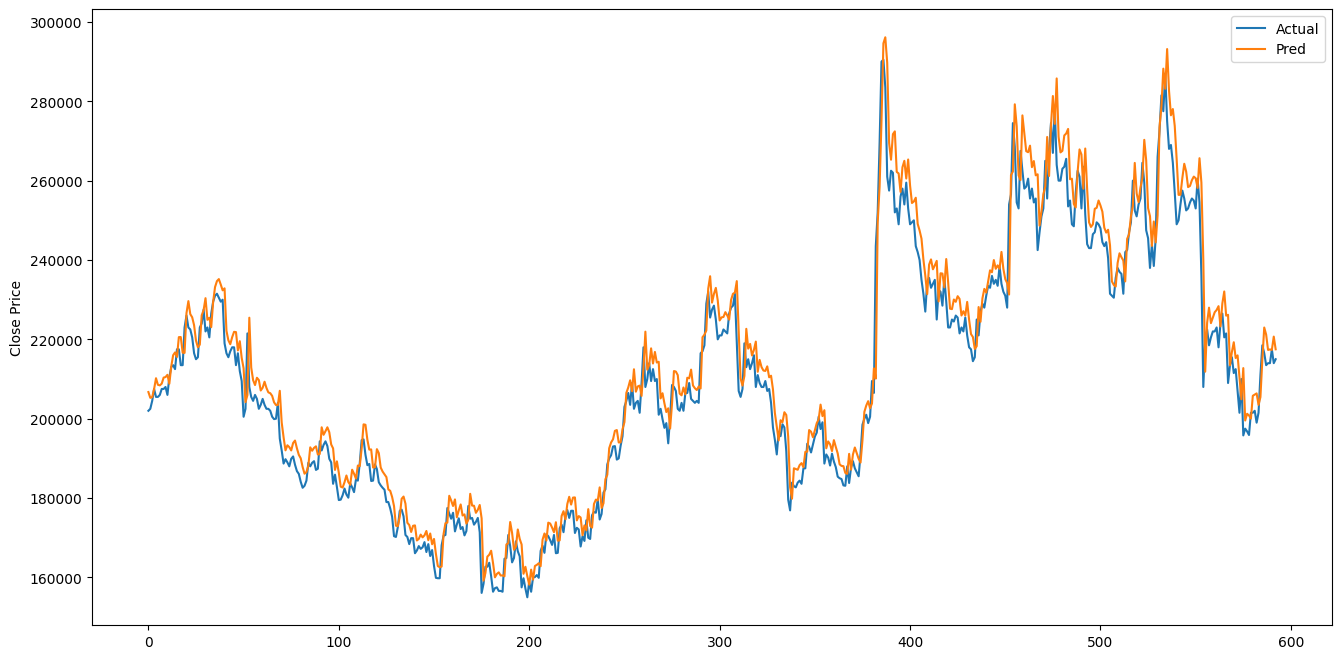

In [28]:
plt.figure(figsize=(16, 8))
plt.plot(y_val_inverse, label='Actual')
plt.plot(pred_inverse, label='Pred')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [29]:
mae = mean_absolute_error(y_val_inverse, pred_inverse)
rmse = np.sqrt(mean_squared_error(y_val_inverse, pred_inverse))

print('MAE:', mae)
print('RMSE:', rmse)

MAE: 5356.61865234375
RMSE: 6926.079121696488


## 10. 다음 날 종가 예측 함수 만들기

최근 `window_size`일의 feature 데이터를 입력받아 다음 날 종가를 예측하는 함수를 만든다.


In [30]:
def predict_next_close(stock_df, model, feature_cols, feature_scaler, target_scaler, window_size=20):
    # 최근 window_size일의 feature만 사용
    recent_features = stock_df[feature_cols].values[-window_size:]

    # feature 스케일링
    recent_scaled = feature_scaler.transform(recent_features)

    # 모델 입력 형태: (batch_size, seq_len, input_size)
    input_tensor = torch.tensor(recent_scaled, dtype=torch.float).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        pred_scaled = model(input_tensor).detach().numpy()

    # 예측값 역스케일링
    pred_inverse = target_scaler.inverse_transform(pred_scaled)

    return pred_inverse[0, 0]


next_price = predict_next_close(
    stock_df,
    model,
    feature_cols,
    feature_scaler,
    target_scaler,
    window_size=window_size
)

print('예측 다음 종가:', next_price)

예측 다음 종가: 218308.34


### 단일 feature 예제와 다중 feature 예제의 입력 shape의 다른 점?

단일 feature 예제에서는 각 시점마다 사용하는 값이 1개였기 때문에 입력 shape이 다음과 같았다.
- (batch_size, seq_len, 1)

다중 feature 예제에서는 각 시점마다 여러 개의 값을 함께 사용하므로 입력 shape이 다음과 같다.
- (batch_size, seq_len, feature_size)

### feature를 늘렸다고 해서 항상 성능이 좋아진다고 말할 수 없는 이유는?

feature가 늘어나면 모델이 참고할 수 있는 정보가 많아지는 장점은 있다. 하지만 항상 성능이 좋아지는 것은 아니다.

- 예측에 도움이 되지 않는 feature가 섞이면 오히려 노이즈가 증가할 수 있다.
- feature 수가 많아지면 모델이 학습 데이터에 과하게 맞춰지는 과적합 위험이 커질 수 있다.
- 서로 비슷한 의미를 가진 feature가 많으면 모델이 불필요하게 복잡해질 수 있다.
- 주가 데이터처럼 변동성이 큰 데이터에서는 추가 feature가 미래 가격을 안정적으로 설명하지 못할 수 있다.
- 검증 데이터에서는 좋아 보여도 실제 미래 데이터에서는 성능이 떨어질 수 있다.

따라서 feature를 늘릴 때는 단순히 많이 넣는 것이 아니라, 어떤 feature가 실제로 예측에 도움이 되는지 검증해야 한다.

### 주가 예측 그래프가 그럴듯해 보여도 실제 예측력이 높다고 단정하면 안 되는 이유는?

주가 예측 그래프는 실제값과 예측값이 비슷하게 보일 수 있지만, 그것만으로 모델의 예측력이 높다고 단정하면 안 된다.

특히 주가 데이터는 연속적인 값이기 때문에, 모델이 실제로 미래 변화를 정확히 맞췄다기보다 이전 가격 흐름을 따라가는 형태로 보일 수 있다. 이 경우 그래프는 그럴듯하지만, 상승과 하락의 전환점이나 급격한 변동을 제대로 예측하지 못할 수 있다.

또한 그래프의 스케일이 크면 작은 오차가 잘 보이지 않을 수 있고, 시각적으로는 비슷해 보여도 RMSE, MAE 같은 수치 지표에서는 차이가 클 수 있다.

따라서 주가 예측 결과는 그래프만 보고 판단하지 말고, 다음과 함께 확인해야 한다.

- 검증 데이터 기준 손실
- MAE, RMSE 같은 회귀 평가 지표
- 단순 기준 모델과의 비교
- 실제 미래 구간에 대한 테스트
- 상승/하락 방향을 맞추는지 여부

즉, 그래프는 결과를 이해하는 보조 자료일 뿐이며, 실제 예측 성능은 별도의 평가 기준으로 확인해야 한다.